#### **Problem Statement: Customer Lifestyle Hierarchy Analysis**

You are a Data Scientist at a retail company. The business aims to move beyond traditional customer segmentation and gain deeper insights into customer behavior patterns.

The objective of this project is to analyze customers based on their demographic and spending characteristics, such as Age, Annual Income, and Spending Score, and identify distinct groups that reflect different lifestyle patterns.

Unlike basic clustering approaches, the goal is to understand how customer segments are hierarchically related, and how smaller groups combine to form broader customer categories.

#### **Objective :**
- Analyze customer data using Age, Annual Income, and Spending Score
- Identify meaningful customer groups representing different lifestyle patterns
- Understand hierarchical relationships between customer segments
- Analyze how smaller clusters merge into larger clusters using Agglomerative Hierarchical Clustering
- Enable data-driven, targeted, and personalized marketing strategies

In [1]:
# Step No 1 : Importing Required Libraries : 

import pandas as pd                   # Data Manipulation
import numpy as np                    # Numerical Computation
import matplotlib.pyplot as plt       # Data Visualization
import seaborn as sns                 # Advanced  Visualization

from sklearn.preprocessing import StandardScaler        # Feature Scaling
from sklearn.cluster import AgglomerativeClustering     # Hierarchical Clustering model
from sklearn.metrics import silhouette_score            # Cluster separation score
from sklearn.metrics import davies_bouldin_score        # Cluster Overlap score
from sklearn.metrics import calinski_harabasz_score     # Cluster quality score
import scipy.cluster.hierarchy as sch                 # Dendrogram plotting


In [20]:
# Step No 2 : Load the Dataset : 
df = pd.read_csv("ecommerce_customers_with_age.csv")    # Read CSB file

print(df.head())   # Display the first 5 rows of the dataset
print(df.info())   # Check data types and null values 
print(df.describe())   # Statistical summary of the dataset



   Customer_ID  Age  Annual_Income  Spending_Score  Purchase_Frequency  \
0            1   56          40342              95                  18   
1            2   46         121308              10                  47   
2            3   32         121081              19                  41   
3            4   25         104045              58                  49   
4            5   38          49698              96                  14   

   Average_Order_Value  
0                 2796  
1                 2761  
2                 2786  
3                 4702  
4                 3378  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Customer_ID          200 non-null    int64
 1   Age                  200 non-null    int64
 2   Annual_Income        200 non-null    int64
 3   Spending_Score       200 non-null    int64
 4   Purchase

In [3]:
# Step No 3 : Data Preprocessing :

# Check for missing values
print("\nMissing Values :\n", df.isnull().sum())   # Count missing values 
print("\nDuplicate Rows :",df.duplicated().sum())  # Count duplicate rows 


Missing Values :
 Customer_ID            0
Age                    0
Annual_Income          0
Spending_Score         0
Purchase_Frequency     0
Average_Order_Value    0
dtype: int64

Duplicate Rows : 0


In [4]:
# Step NO 4  : Select clustering features 

features = [
    "Age",
    "Annual_Income",
    "Spending_Score",
    "Purchase_Frequency",
    "Average_Order_Value"
]

X = df[features]       # Create feature dataset
print(X.head())        # Preview selected features

   Age  Annual_Income  Spending_Score  Purchase_Frequency  Average_Order_Value
0   56          40342              95                  18                 2796
1   46         121308              10                  47                 2761
2   32         121081              19                  41                 2786
3   25         104045              58                  49                 4702
4   38          49698              96                  14                 3378


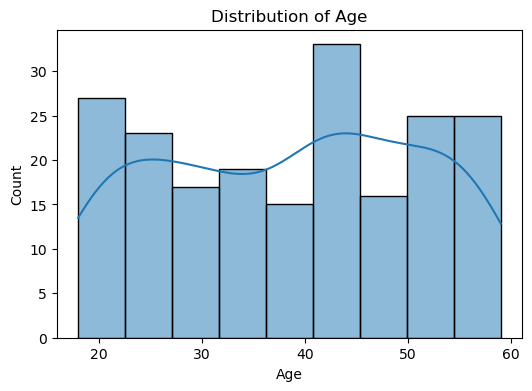

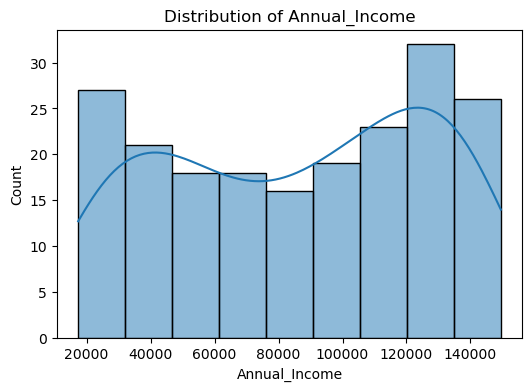

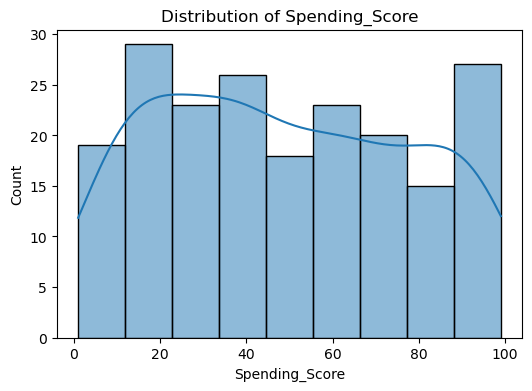

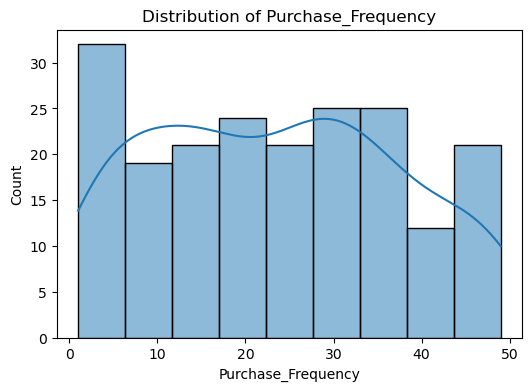

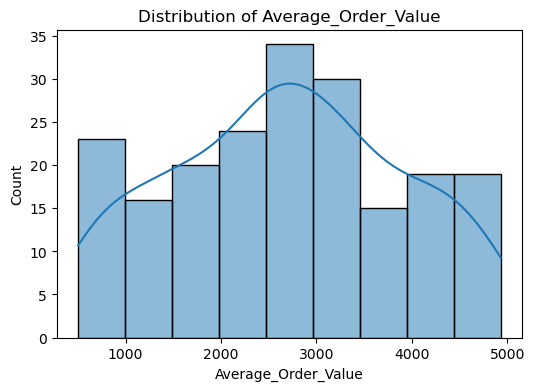

In [5]:
# Step No 5 : Univariate EDA 

for col in features :
    plt.figure(figsize=(6,4))                       # Set chart size
    sns.histplot(df[col] , kde=True)                #Plot distribution
    plt.title(f"Distribution of {col}")             # Add title
    plt.xlabel(col)                                 # Add x-axis label
    plt.ylabel("Count")                             # Add y-axis label
    filename = f"images/{col}_distribution.png"
    plt.savefig(filename)
    plt.show()

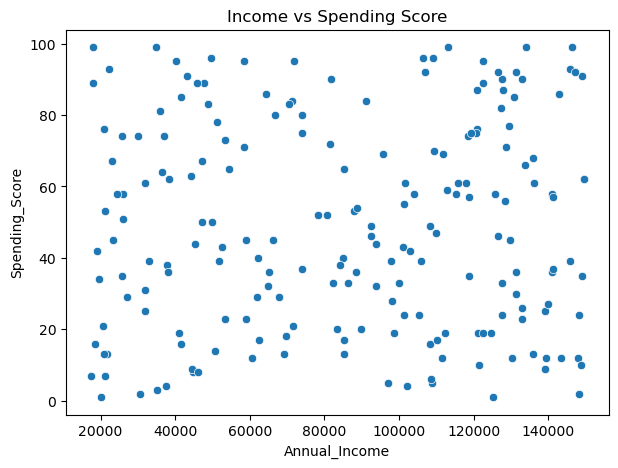

In [6]:
# Step No 6 : Bivariate EDA - Income Vs Spending Score 

plt.figure(figsize=(7,5))      # Set chart size
sns.scatterplot(
    data= df , 
    x = "Annual_Income" ,
    y = "Spending_Score" 
)
plt.title("Income vs Spending Score")   # Add title
plt.savefig("images/income_vs_spending_score(Bivariate).png")  # Save the plot
plt.show()   # Display the plot

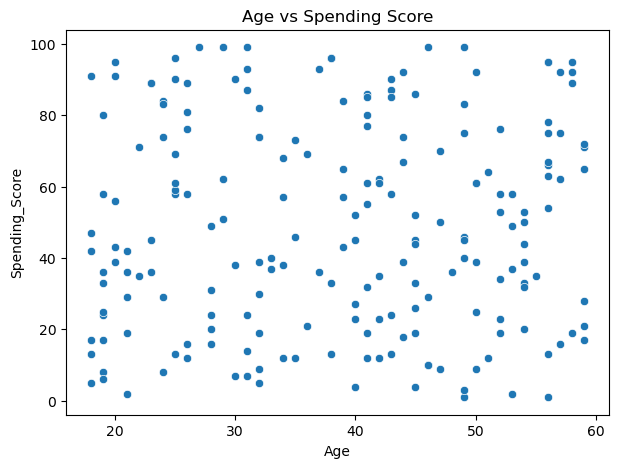

In [7]:
# Step No 7 : Bivariate EDA - Age Vs Spending Score

plt.figure(figsize=(7,5))      # Set chart size
sns.scatterplot(
    data = df , 
    x = "Age",
    y = "Spending_Score"
)
plt.title("Age vs Spending Score")   # Add title
plt.savefig("images/age_vs_spending_score(Bivariate).png")  # Save the plot
plt.show()   # Display the plot

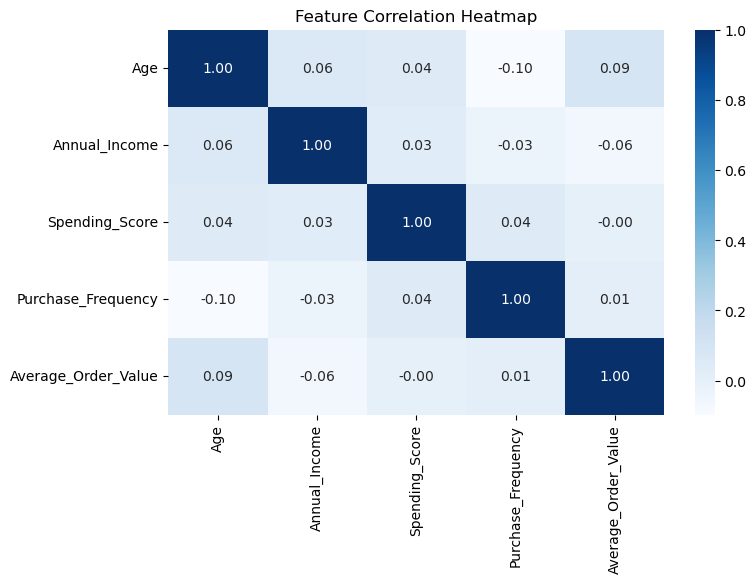

In [8]:
# Step No 8 : Correlation Analysis

plt.figure(figsize=(8,5))     # Set chart size
sns.heatmap(
    X.corr(),
    annot= True,
    cmap = "Blues",
    fmt = ".2f"
)
plt.title("Feature Correlation Heatmap")   # Add title
plt.savefig("images/feature_correlation_heatmap.png")  # Save the plot
plt.show()   # Display the plot

In [9]:
# Step No 9 : Feature Scaling

scaler = StandardScaler()     # Create scaler object
X_scaled = scaler.fit_transform(X)    # Scale the features
print(X_scaled[:5])   # Display the first 5 rows of scaled features

[[ 1.37873744 -1.12021816  1.60450697 -0.38717975  0.09303327]
 [ 0.58338847  0.85121385 -1.33383392  1.68253687  0.06394349]
 [-0.53010009  0.84568665 -1.02271548  1.25431964  0.0847219 ]
 [-1.08684437  0.430879    0.32546447  1.82527595  1.67717946]
 [-0.05289071 -0.89240997  1.63907569 -0.6726579   0.57675472]]


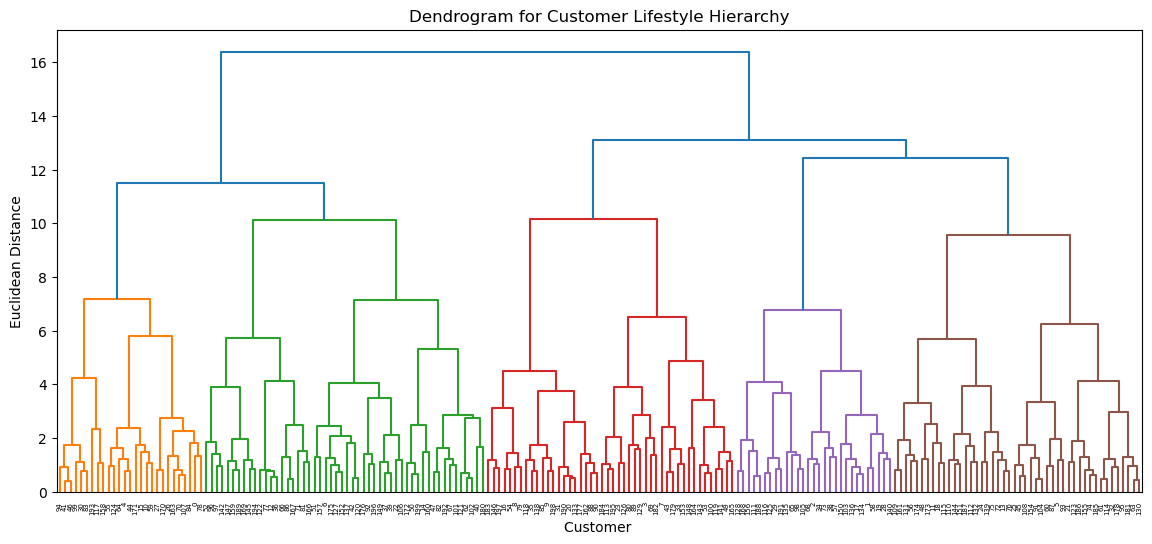

In [10]:
# Step No 10 : Dendrogram : 

plt.figure(figsize=(14,6))

dendrogram = sch.dendrogram(
    sch.linkage(X_scaled , method="ward") # Build hierarchy using Ward
)
plt.title("Dendrogram for Customer Lifestyle Hierarchy")   # Add title
plt.xlabel("Customer ")                                    # Add x-axis label 
plt.ylabel("Euclidean Distance")                           # Add y-axis label
plt.savefig("images/Dendrogram for Customer.png")
plt.show()

In [11]:
# Step No 11 : Comapre different cluster numbers

results = []    # List to store evaluation results

for k in range(2 , 8):
    temp_model = AgglomerativeClustering(
        n_clusters = k,
        linkage = "ward"
    )
    
    temp_labels = temp_model.fit_predict(X_scaled)   # Fit and predict cluster labels
    
    results.append({
        "Clusters": k , 
        "silhouette_score": round(silhouette_score(X_scaled , temp_labels) , 3),
        "Davies- Bouldin Score": round(davies_bouldin_score(X_scaled , temp_labels) , 3),
        "Calinski_Harabasz Score": round(calinski_harabasz_score(X_scaled , temp_labels) , 3)
    })
    
evaluation_df = pd.DataFrame(results)   # Create DataFrame from results
print(evaluation_df)   # Display evaluation results

   Clusters  silhouette_score  Davies- Bouldin Score  Calinski_Harabasz Score
0         2             0.127                  2.418                   30.735
1         3             0.113                  2.244                   27.817
2         4             0.112                  1.859                   27.662
3         5             0.124                  1.773                   27.867
4         6             0.126                  1.649                   27.571
5         7             0.138                  1.573                   28.136


In [12]:
# Step No 12 : Select best cluster number 

best_k = evaluation_df.sort_values(
    by = ["silhouette_score" , "Calinski_Harabasz Score"],
    ascending = [False , False]
).iloc[0]["Clusters"]

best_k = int(best_k)   # Convert to integer
print("Best number of clusters : " , best_k)

Best number of clusters :  7


In [13]:
# Step No 13 : Build final Agglomerative model 

model = AgglomerativeClustering(
    n_clusters= best_k,     # Best cluster nubmer from evaluation
    linkage= "ward"          # Use Ward linkage
)

df["Cluster"] = model.fit_predict(X_scaled)   # Fit model and assign cluster labels
print(df.head())
print("\nCluster Counts :\n", df["Cluster"].value_counts())   # Count of customers in each cluster

   Customer_ID  Age  Annual_Income  Spending_Score  Purchase_Frequency  \
0            1   56          40342              95                  18   
1            2   46         121308              10                  47   
2            3   32         121081              19                  41   
3            4   25         104045              58                  49   
4            5   38          49698              96                  14   

   Average_Order_Value  Cluster  
0                 2796        1  
1                 2761        3  
2                 2786        3  
3                 4702        2  
4                 3378        1  

Cluster Counts :
 Cluster
0    46
4    32
3    29
1    27
2    25
5    21
6    20
Name: count, dtype: int64


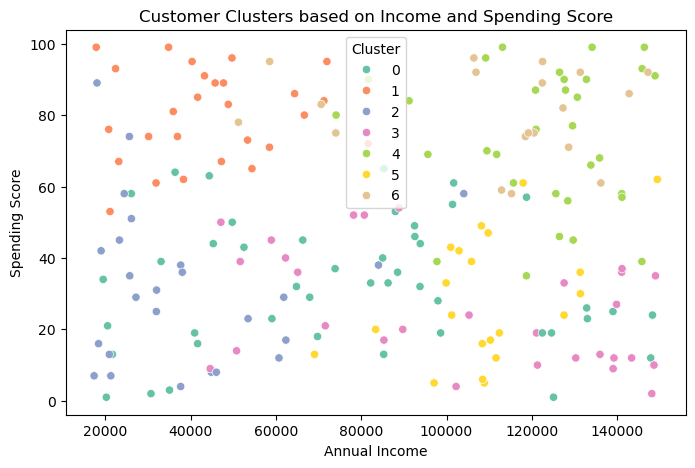

In [14]:
# Step No 14 : Cluster Visualization 

plt.figure(figsize = (8,5))   # Set chart size
sns.scatterplot(
    data = df,
    x = "Annual_Income",
    y = "Spending_Score",
    hue = "Cluster",
    palette = "Set2"
)
plt.title("Customer Clusters based on Income and Spending Score")   # Add title
plt.xlabel("Annual Income")   # Add x-axis label
plt.ylabel("Spending Score")   # Add y-axis label
plt.savefig("images/Customer_Clusters.png")  # Save the plot
plt.show()   # Display the plot

In [15]:
# Step No 15 : Cluster Profiling

cluster_profile = df.groupby("Cluster")[features].mean().round(2)   # Calculate mean of features for each cluster
print(cluster_profile)   # Display cluster profiles

           Age  Annual_Income  Spending_Score  Purchase_Frequency  \
Cluster                                                             
0        47.87       78772.28           32.09               13.87   
1        37.70       44441.26           80.00               29.74   
2        26.28       38488.52           31.72               23.32   
3        42.34      103724.10           25.66               40.17   
4        37.19      122446.75           73.47               30.84   
5        23.19      109327.81           28.71               16.67   
6        47.55      113098.00           79.50                7.95   

         Average_Order_Value  
Cluster                       
0                    2883.24  
1                    2849.63  
2                    3329.20  
3                    2336.00  
4                    2980.94  
5                    1980.05  
6                    1964.95  


In [16]:
# Step No 16 : Final Cluster Evaluation

labels = df["Cluster"]   # Cluster labels from the final model

silhouette = silhouette_score(X_scaled , labels)   # Higher is better 
db_score = davies_bouldin_score(X_scaled , labels)  # Lower is better
ch_score = calinski_harabasz_score(X_scaled , labels) # Higher is better 

print("Final Silhouette Score : ", round(silhouette , 3))
print("Final Davies-Bouldin Score : ", round(db_score , 3))
print("Final Calinski-Harabasz Score : ", round(ch_score , 3))

Final Silhouette Score :  0.138
Final Davies-Bouldin Score :  1.573
Final Calinski-Harabasz Score :  28.136


In [19]:
# Step 17 : Business Segment Naming

profile = df.groupby("Cluster")[features].mean()

segment_names = {}

avg_income = profile["Annual_Income"].mean()
avg_spending = profile["Spending_Score"].mean()

for cluster in profile.index:
    income = profile.loc[cluster, "Annual_Income"]
    spending = profile.loc[cluster, "Spending_Score"]
    
    if income >= avg_income and spending >= avg_spending:
        segment_names[cluster] = "Premium High-Spending Customers"
        
    elif income >= avg_income and spending < avg_spending:
        segment_names[cluster] = "High Income Careful Spenders"
        
    elif income < avg_income and spending >= avg_spending:
        segment_names[cluster] = "Frequent Budget Customers"
        
    else:
        segment_names[cluster] = "Low Engagement Customers"

df["Customer_Segment"] = df["Cluster"].map(segment_names)

print(df[[
    "Customer_ID",
    "Age",
    "Annual_Income",
    "Spending_Score",
    "Cluster",
    "Customer_Segment"
]].head())

   Customer_ID  Age  Annual_Income  Spending_Score  Cluster  \
0            1   56          40342              95        1   
1            2   46         121308              10        3   
2            3   32         121081              19        3   
3            4   25         104045              58        2   
4            5   38          49698              96        1   

               Customer_Segment  
0     Frequent Budget Customers  
1  High Income Careful Spenders  
2  High Income Careful Spenders  
3      Low Engagement Customers  
4     Frequent Budget Customers  


#### Step : 18 : **Business Impact :**

* This project helps businesses understand customer behavior beyond traditional segmentation by identifying lifestyle-based customer groups.

* Using hierarchical clustering, customers are segmented into meaningful groups such as premium customers, budget buyers, and careful spenders.

* These insights enable businesses to:

        - Retain high-value customers through loyalty and premium services.
        - Increase revenue by targeting high-income but low-spending customers.
        - Identify risky customers and optimize financial strategies.
        - Reduce unnecessary marketing costs by avoiding low-engagement segments.

* Overall, this model supports data-driven decision-making, improves customer targeting, and enhances revenue optimization strategies.

* This approach helps businesses move from generic marketing to personalized customer engagement.

#### Step No 19 : **Project Conclusion :** 

- In this project, customer data was analyzed using demographic and behavioral features such as age, income, spending score, purchase frequency, and average order value.

- Exploratory Data Analysis (EDA) revealed that no strong linear relationship exists between features, indicating complex customer behavior patterns.

- Feature scaling was applied to ensure fair distance-based clustering. Agglomerative Hierarchical Clustering was used to identify customer groups, supported by dendrogram analysis and evaluation metrics.

- Although the optimal number of clusters suggested by metrics was higher, the final segmentation was interpreted based on business usability and clarity.

- Cluster profiling helped in identifying meaningful customer segments such as premium customers, careful spenders, and low-engagement users.

- However, evaluation metrics indicated moderate cluster separation, suggesting that further optimization can improve clustering performance.

- Overall, this project demonstrates how machine learning can be used to uncover hidden customer patterns and support strategic business decisions.